# MODIS time series analysis using LSTM

This notebook demonstrates how **Long Short-Term Memory (LSTM) networks** can be used to model **satellite vegetation time series**.

The dataset contains **MODIS NDVI observations for a number of pixels over time**. Each pixel represents a spatial location and contains a sequence of observations.

The main goals of this notebook are:

1. Explore the structure of the MODIS time series dataset
2. Perform basic data preprocessing
3. Construct sequential inputs for machine learning
4. Train an **LSTM model** to learn temporal patterns in NDVI
5. Evaluate the model's predictions

This workflow illustrates how **sequential deep learning models can be applied to remote sensing data**.

#### Import Required Libraries

We first import the main Python libraries used in this analysis.

Key libraries include:

- **NumPy** – numerical computations
- **Pandas** – data manipulation and tabular data handling
- **Matplotlib** – visualization

In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

#### Access Dataset

  
The following step mounts the Google Drive so the notebook can access the file.

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
file_url = "https://drive.google.com/uc?id=1DBNYHyqKLQMH_uoJrvaTCMBy4aWH7ncL"

#### Load the MODIS Dataset

The dataset contains time series observations of **NDVI values** for multiple spatial pixels.

Each row corresponds to a single observation and contains:

- **time** – observation timestamp
- **pixel** – spatial pixel identifier
- **ndvi** – vegetation index value
- **qa** – quality flag

The data is sorted by **time and pixel ID** to ensure correct temporal ordering.

In [5]:
# Load the dataset
# df = pd.read_csv("/content/drive/MyDrive/Public/LSTM/data.csv")
df = pd.read_csv(file_url)

# Sort observations by time and pixel
df.sort_values(['time','pixel'], inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 502550 entries, 10 to 74267
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   pixel       502550 non-null  int64  
 1   year        502550 non-null  int64  
 2   ndvi        502550 non-null  float64
 3   evi         502550 non-null  float64
 4   qa          502550 non-null  float64
 5   lai         502550 non-null  float64
 6   time        502550 non-null  object 
 7   land_cover  476100 non-null  float64
 8   lc_time     476100 non-null  object 
dtypes: float64(5), int64(2), object(2)
memory usage: 38.3+ MB


In [7]:
df.head()

,pixel,year,ndvi,evi,qa,lai,time,land_cover,lc_time
10,1,2001,0.580022,0.229722,1.000000,0.050433,2001-01-01,7.0,2001-01-01
114507,2,2001,0.413389,0.162797,0.545617,0.045434,2001-01-01,8.0,2001-01-01
163005,3,2001,0.376526,0.148463,0.000000,0.045796,2001-01-01,8.0,2001-01-01
211510,4,2001,0.532181,0.207942,0.000000,0.051338,2001-01-01,5.0,2001-01-01
260025,5,2001,0.719637,0.280162,0.000000,0.055572,2001-01-01,4.0,2001-01-01


#### Pixel-based Time Series

Each **pixel represents a spatial location**, approximately covering a **250 × 250 meter area**.

For each pixel we have a sequence of **437 time observations**.

This means that each pixel forms a **time series**, which can be used as input to a sequential model such as an LSTM.

#### Number of Observations per Pixel

This step verifies how many time observations exist for each pixel.  
Ideally, each pixel should have a similar number of observations so that sequences can be constructed consistently.

In [8]:
df['pixel'].value_counts()

,count
pixel,
1150,437
1,437
2,437
3,437
4,437
...,...
34,437
35,437
36,437


#### Quality Flag Analysis

Satellite datasets often include **quality flags (QA)** indicating the reliability of each observation.

These flags may represent issues such as:

- cloud contamination
- sensor noise
- atmospheric interference

Visualizing the distribution of QA values helps assess the **overall quality of the dataset**.

<Axes: >

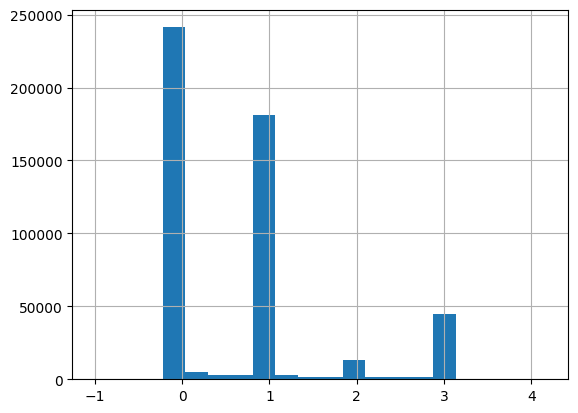

In [9]:
df['qa'].hist(bins=20)

#### NDVI Time Series Example

To better understand the temporal structure of the dataset, we visualize the NDVI values for a **single pixel**.

This allows us to observe:

- seasonal vegetation dynamics
- noise in the measurements
- potential missing or abnormal values

/tmp/ipykernel_2774/4088343264.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(subset['time'], subset['ndvi'], cmap='viridis', s=5)


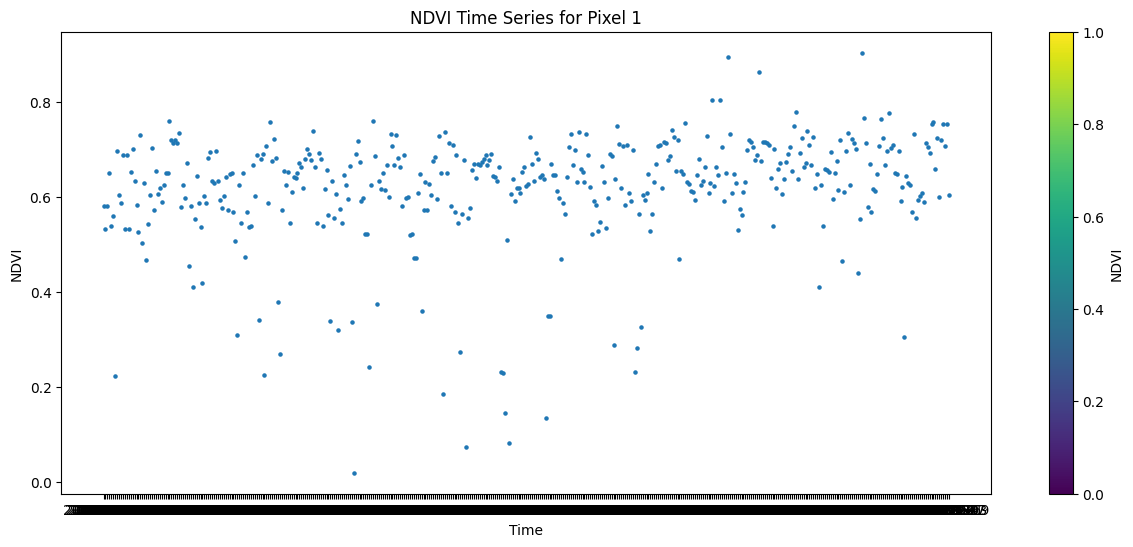

In [10]:
# Select one pixel to visualize its NDVI time series
subset = df[(df['pixel'] == 1)]

plt.figure(figsize=(15, 6))

# Scatter plot of NDVI values over time
scatter = plt.scatter(subset['time'], subset['ndvi'], cmap='viridis', s=5)

plt.colorbar(scatter, label='NDVI')
plt.title("NDVI Time Series for Pixel 1")
plt.xlabel("Time")
plt.ylabel("NDVI")
plt.show()

In [11]:
df.isna().sum()

,0
pixel,0
year,0
ndvi,0
evi,0
qa,0
lai,0
time,0
land_cover,26450
lc_time,26450


In [12]:
df = df.dropna()

####  Data exploration

In [13]:
df.groupby('pixel').count()

,year,ndvi,evi,qa,lai,time,land_cover,lc_time
pixel,,,,,,,,
1,414,414,414,414,414,414,414,414
2,414,414,414,414,414,414,414,414
3,414,414,414,414,414,414,414,414
4,414,414,414,414,414,414,414,414
5,414,414,414,414,414,414,414,414
...,...,...,...,...,...,...,...,...
1146,414,414,414,414,414,414,414,414
1147,414,414,414,414,414,414,414,414
1148,414,414,414,414,414,414,414,414


#### Low quality values

We can see that there are a lot of abnormal values or outliers.
Thus, we need to filter them ased on the QA column.

There are two strategies to process these low quality or abnormal values

1 to remove them

2 to fill them with mean of neaby locations

#### Low quality and abnormal values

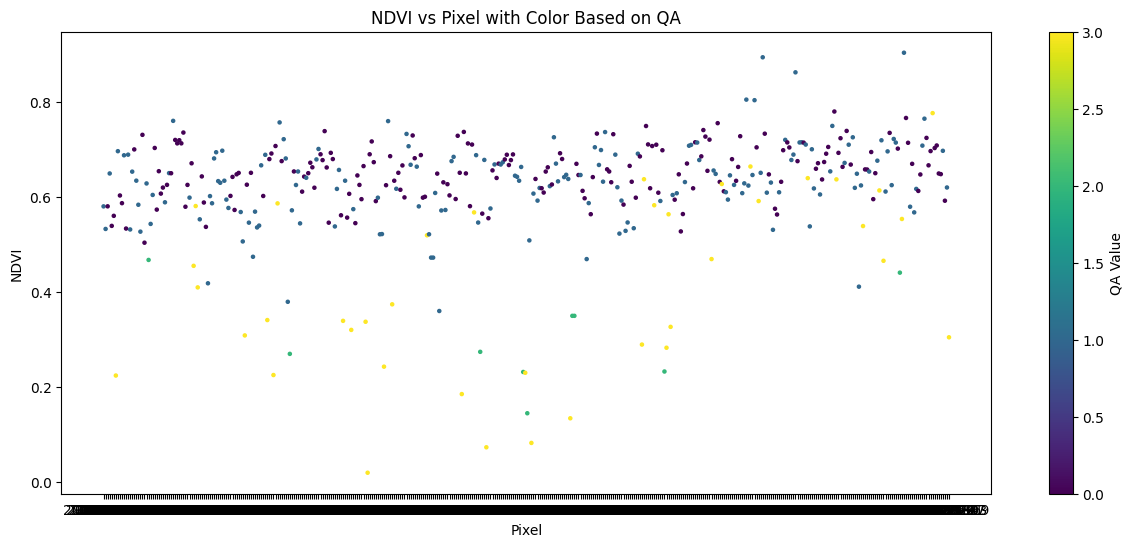

In [14]:
subset = df[
            (df['pixel']==1) &
            (df['qa']>=0) &
            (df['qa']<=5)
             ]

plt.figure(figsize=(15, 6))
scatter = plt.scatter(subset['time'], subset['ndvi'], c=subset['qa'], cmap='viridis', s=5)

plt.colorbar(scatter, label='QA Value')
plt.xlabel('Pixel')
plt.ylabel('NDVI')
plt.title('NDVI vs Pixel with Color Based on QA')
plt.show()

<Axes: >

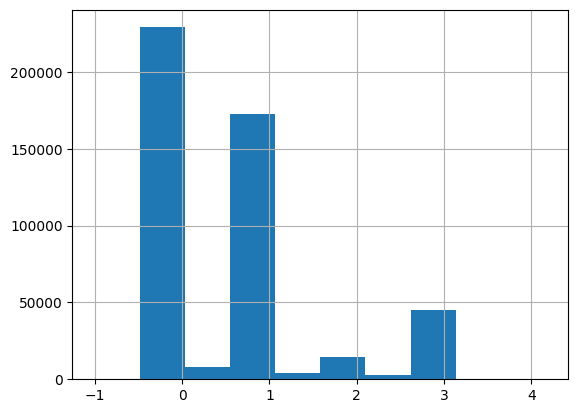

In [15]:
df.qa.hist()

In [17]:
df['time'] = pd.to_datetime(df['time'])

In [18]:
df.time

,time
10,2001-01-01
114507,2001-01-01
163005,2001-01-01
211510,2001-01-01
260025,2001-01-01
...,...
72074,2018-12-19
72512,2018-12-19
72952,2018-12-19
73384,2018-12-19


In [19]:
df = df.sort_values(by=['pixel', 'time'])

In [20]:
df.head()

,pixel,year,ndvi,evi,qa,lai,time,land_cover,lc_time
10,1,2001,0.580022,0.229722,1.0,0.050433,2001-01-01,7.0,2001-01-01
13,1,2001,0.532502,0.104392,1.0,0.090200,2001-01-17,7.0,2001-01-01
7,1,2001,0.580141,0.277603,0.0,0.010000,2001-02-02,7.0,2001-01-01
8,1,2001,0.649355,0.240046,1.0,0.080180,2001-02-18,7.0,2001-01-01
20,1,2001,0.538956,0.242287,0.0,0.082812,2001-03-06,7.0,2001-01-01


#### Preparing Sequential Data for LSTM

LSTM networks require input data in the form of **sequences**.

Instead of using single observations, we construct sliding windows of previous time steps.

Example:

Input sequence:

t-5, t-4, t-3, t-2, t-1

Target:
t

This allows the model to learn **temporal dependencies in NDVI dynamics**.

In [21]:
from sklearn.model_selection import train_test_split

features = []

# Function to create sequences of data for LSTM
def create_sequences(df, seq_length=3):
    sequences = []
    targets = []
    for pixel in df['pixel'].unique():
        pixel_data = df[df['pixel'] == pixel]
        for i in range(len(pixel_data) - seq_length):
            seq = pixel_data.iloc[i:i+seq_length].drop(columns=['pixel', 'time', 'lc_time']).values  # Drop non-input features
            target = pixel_data.iloc[i + seq_length]['ndvi']  # The value to predict (e.g., ndvi)
            sequences.append(seq)
            targets.append(target)

    return np.array(sequences), np.array(targets)

# Create sequences
seq_length = 10
X, y = create_sequences(df[0:100000], seq_length)

# Split into train and test sets (make sure the split is done per pixel and chronologically)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (78064, 10, 6)
X_test shape: (19516, 10, 6)
y_train shape: (78064,)
y_test shape: (19516,)


#### LSTM Model Architecture

We now define an LSTM network to model NDVI time series.

LSTM networks are designed for sequential data and can capture both:

- short-term variations
- long-term seasonal patterns

The model receives sequences of NDVI observations and learns to predict future values.

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [24]:
X_train_tensor = torch.Tensor(X_train)  # Shape: (num_samples, seq_length, num_features)
y_train_tensor = torch.Tensor(y_train)  # Shape: (num_samples,)
X_test_tensor = torch.Tensor(X_test)  # Shape: (num_samples, seq_length, num_features)
y_test_tensor = torch.Tensor(y_test)  # Shape: (num_samples,)

X_train_tensor, X_val_tensor, y_train_tensor, y_val_tensor = train_test_split(
    X_train_tensor, y_train_tensor, test_size=0.2, shuffle=False
)

#### Write a model's class

In [25]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Get the LSTM output (the full sequence) and hidden state (the last output in the sequence)
        lstm_out, (hn, cn) = self.lstm(x)
        # We use the last hidden state to predict the output (for time series prediction)
        out = self.fc(hn[-1])  # Take the last hidden state
        return out

In [26]:
# Hyperparameters
input_size = X_train.shape[2]  # Number of features
hidden_size = 50  # Number of hidden units in LSTM layer
output_size = 1
num_layers = 1
learning_rate = 0.001
num_epochs = 50

# Instantiate the model
model = LSTMModel(input_size, hidden_size, output_size, num_layers)
model.to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

#### Model Training

In [27]:
train_losses = []
val_losses = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass (Training)
    y_train_pred = model(X_train_tensor.to(device))

    # Compute training loss
    train_loss = criterion(y_train_pred.squeeze(), y_train_tensor.to(device))

    # Backward pass and optimization
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val_tensor.to(device))

        val_loss = criterion(y_val_pred.squeeze(), y_val_tensor.to(device))

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}")


Epoch [1/50], Train Loss: 0.3841, Val Loss: 0.3635
Epoch [2/50], Train Loss: 0.3153, Val Loss: 0.3389
Epoch [3/50], Train Loss: 0.2915, Val Loss: 0.1610
Epoch [4/50], Train Loss: 0.1698, Val Loss: 0.1441
Epoch [5/50], Train Loss: 0.1147, Val Loss: 0.1368
Epoch [6/50], Train Loss: 0.1083, Val Loss: 0.1297
Epoch [7/50], Train Loss: 0.1021, Val Loss: 0.1228
Epoch [8/50], Train Loss: 0.0961, Val Loss: 0.1158
Epoch [9/50], Train Loss: 0.0901, Val Loss: 0.1084
Epoch [10/50], Train Loss: 0.0837, Val Loss: 0.0991
Epoch [11/50], Train Loss: 0.0759, Val Loss: 0.0872
Epoch [12/50], Train Loss: 0.0659, Val Loss: 0.0763
Epoch [13/50], Train Loss: 0.0569, Val Loss: 0.0698
Epoch [14/50], Train Loss: 0.0516, Val Loss: 0.0654
Epoch [15/50], Train Loss: 0.0481, Val Loss: 0.0615
Epoch [16/50], Train Loss: 0.0451, Val Loss: 0.0573
Epoch [17/50], Train Loss: 0.0420, Val Loss: 0.0518
Epoch [18/50], Train Loss: 0.0381, Val Loss: 0.0442
Epoch [19/50], Train Loss: 0.0329, Val Loss: 0.0394
Epoch [20/50], Train 

#### Plot the training and validation losses

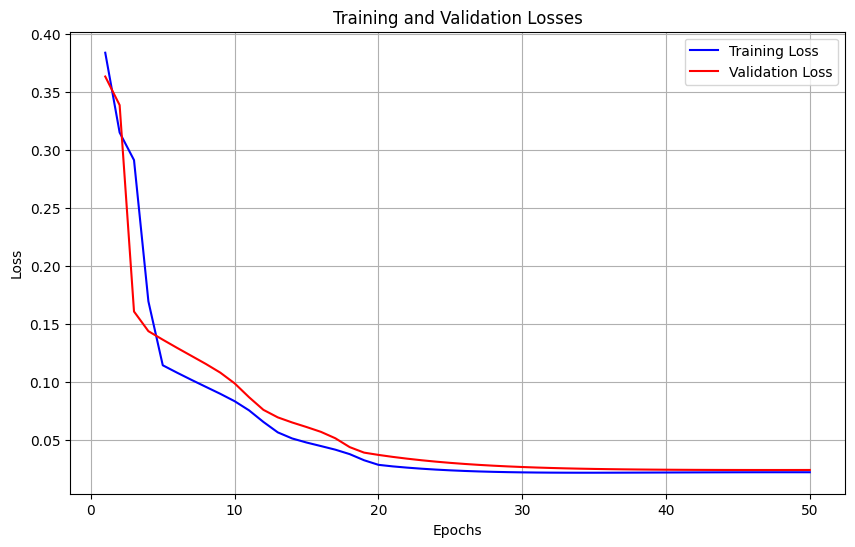

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs+1), train_losses, label="Training Loss", color='blue')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.grid(True)
plt.show()

#### Evaluate the model on the test set

In [29]:
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

model.eval()
with torch.no_grad():
    pred = model(X_test_tensor.squeeze())
    pred = pred.to('cpu')
    test = y_test_tensor.to('cpu')
    test_loss = mean_squared_error(pred, test)
    print(f"Test Mean Squared Error: {test_loss:.4f}")

Test Mean Squared Error: 0.0266


Tasks:
1) Drop rows based on QA flag and fill empty rows (pandas.DataFrame.bfill)
2) Train a model with multiple output targets (multiple target values in each sequence)
3) modify the model